In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Loads the aggregate data generated by query_data.py
df = pd.read_csv('monthly_merchant_trends.csv')

df['total_revenue'] = df['total_revenue'].round(2)
df['avg_transaction_value'] = df['avg_transaction_value'].round(2)

df.head()

In [11]:
# Pivot so index = months, columns = merchants, values = total_revenue
revenue_pivot = df.pivot(index='transaction_month', columns='merchant', values='total_revenue')
revenue_pivot

merchant,Amazon,Best Buy,Etsy,Target,Walmart,eBay
transaction_month,,,,,,
2026-01,1935.29,2349.28,2105.13,6367.39,3574.81,5722.84
2026-02,2023.08,2673.73,4086.44,4778.66,4168.64,3277.69
2026-03,2895.59,4373.18,3163.86,2406.09,2551.07,2446.57


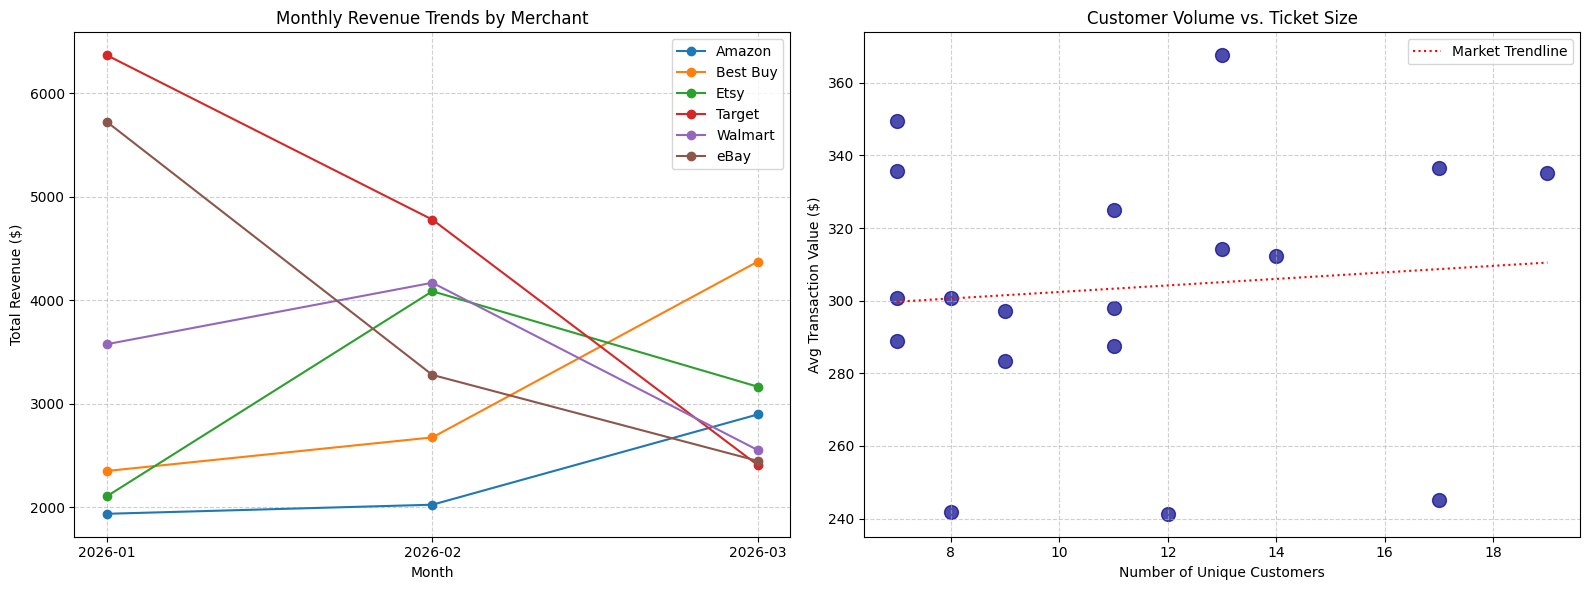

In [12]:
# Create a figure with two distinct subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Total Revenue Trends (Line Chart)
for merchant in revenue_pivot.columns:
    ax1.plot(revenue_pivot.index, revenue_pivot[merchant], marker='o', label=merchant)
ax1.set_title('Monthly Revenue Trends by Merchant')
ax1.set_xlabel('Month')
ax1.set_ylabel('Total Revenue ($)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# Unique Customers vs Average Transaction Value (Scatter Plot + Trendline)
ax2.scatter(df['unique_customers'], df['avg_transaction_value'], color='darkblue', s=100, alpha=0.7)

# Linear regression for plot 2
m, b = np.polyfit(df['unique_customers'], df['avg_transaction_value'], 1)
x_vals = np.array([df['unique_customers'].min(), df['unique_customers'].max()])
ax2.plot(x_vals, m*x_vals + b, color='red', linestyle=':', label='Market Trendline')

ax2.set_title('Customer Volume vs. Ticket Size')
ax2.set_xlabel('Number of Unique Customers')
ax2.set_ylabel('Avg Transaction Value ($)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()